In [ ]:
from matplotlib import pyplot as plt
from PIL import Image
import torch
from torchvision import utils
import os
from src.GalaxyDiffusion import VisualDiffusion, ScoreNet

### Training Progress: Galaxy Generation Evolution

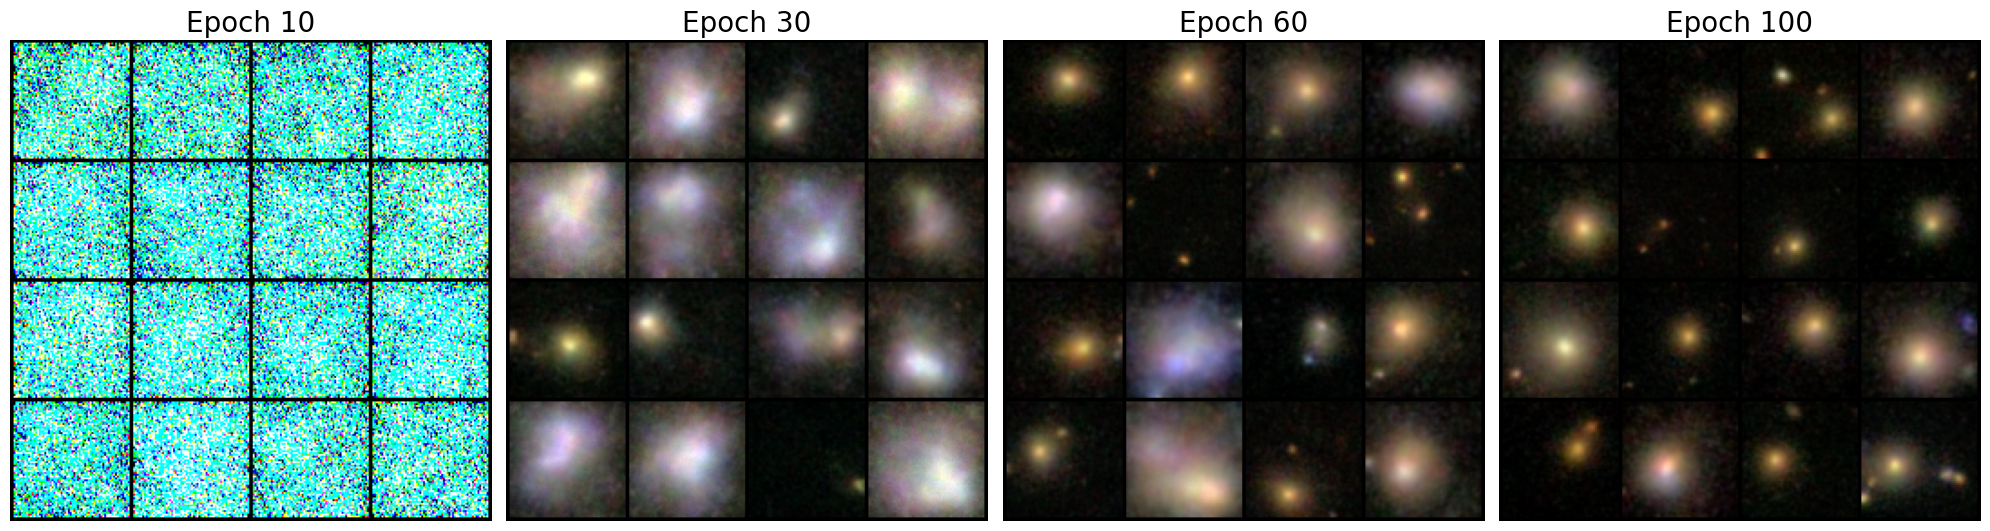

In [8]:
def display_evolution(epochs, folder="Results"):
    fig, axes = plt.subplots(1, len(epochs), figsize=(20, 6))
    
    for i, epoch in enumerate(epochs):
        img_path = os.path.join(folder, f"samples_epoch_{epoch}.png")
        if os.path.exists(img_path):
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(f"Epoch {epoch}", fontsize=20)
            axes[i].axis("off")
        else:
            axes[i].text(0.5, 0.5, f"Missing:\nEpoch {epoch}", 
                         ha='center', fontsize=16)
            axes[i].axis("off")
            
    plt.subplots_adjust(wspace=0.1)
    plt.tight_layout()
    plt.show()

checkpoints = [10, 30, 60, 100]
display_evolution(checkpoints)

This $4 \times 4$ grid tracks 4 distinct galaxies as they are generated. The $x$-axis shows the total number of denoising steps completed, transitioning from pure noise at step 0 to a fully formed image after 1000 steps.

100%|██████████| 1000/1000 [02:09<00:00,  7.71it/s]


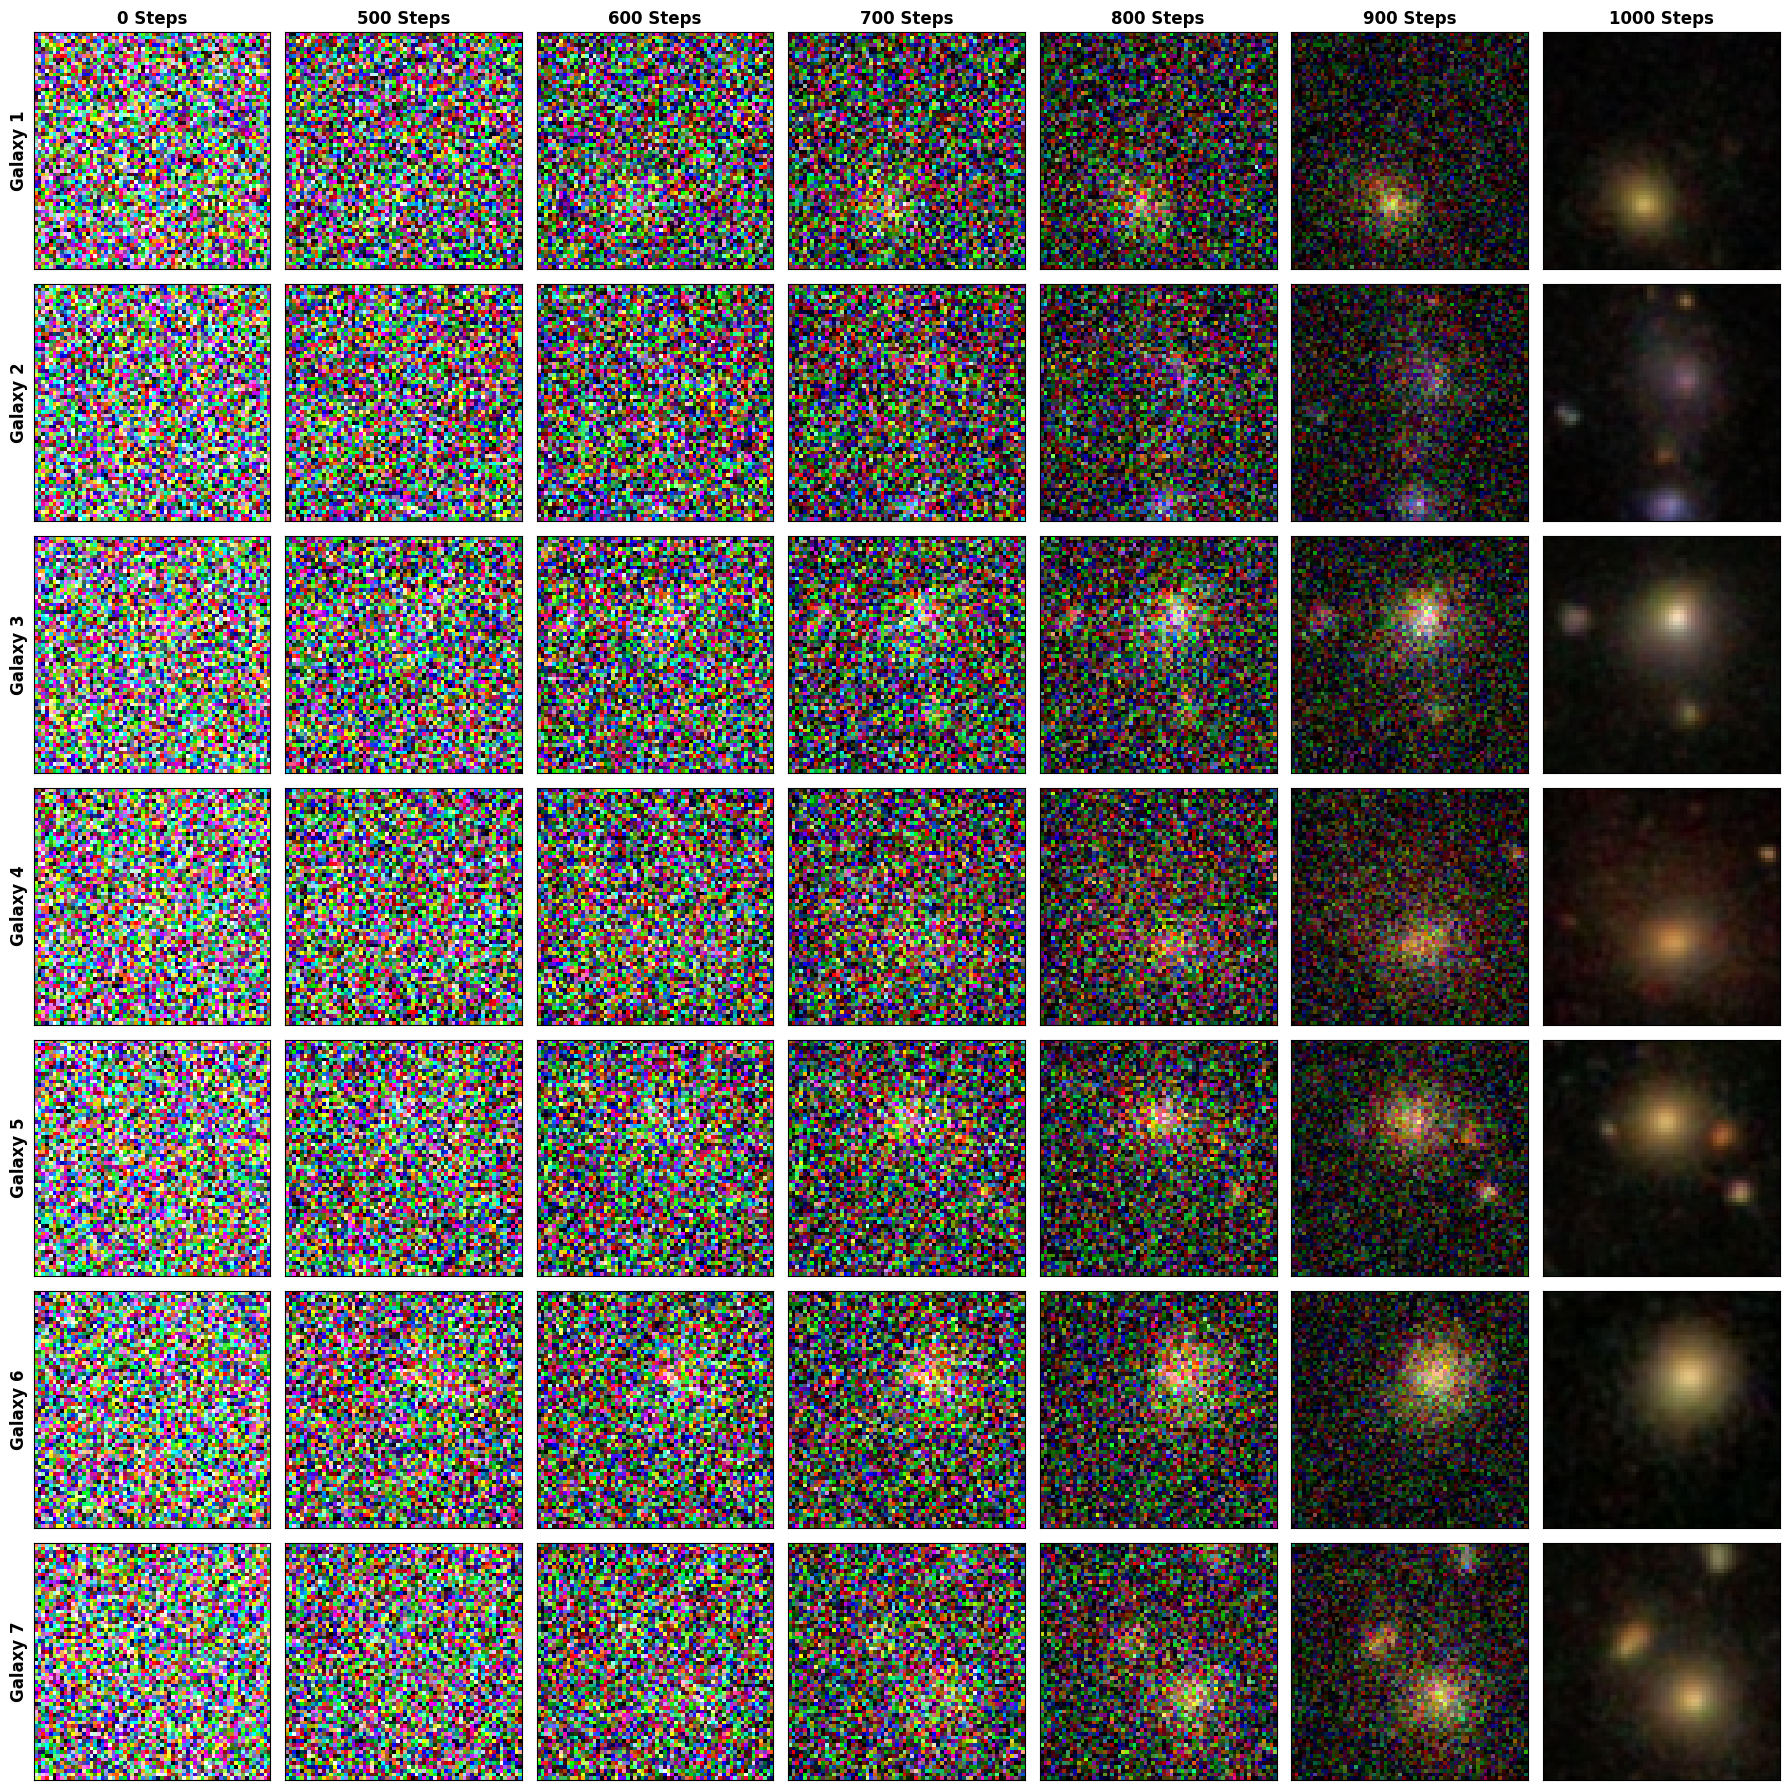

In [12]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
vis_diff = VisualDiffusion(device=device)
steps = [999, 750, 500, 250, 0]
model = ScoreNet().to(device)

state_dict = torch.load("Results/galaxy_diffusion_model.pth", map_location=device)
model.load_state_dict(state_dict)

actual_indices = [999, 500, 400, 300, 200, 100, 0]
display_labels = [0, 500, 600, 700, 800, 900, 1000]
snapshots = vis_diff.sample_evolution(model, n=7, steps_to_save=actual_indices)

fig, axes = plt.subplots(7, 7, figsize=(18, 18))
for col, step_batch in enumerate(snapshots):
    for row in range(7):
        img = step_batch[row].permute(1, 2, 0).numpy()
        ax = axes[row, col]
        ax.imshow(img)
        
        if row == 0:
            ax.set_title(f"{display_labels[col]} Steps", fontsize=12, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f"Galaxy {row+1}", fontsize=12, fontweight='bold')
            
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()